# Rigol DS1000D Waveform Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from RigolWFM import Wfm, DS1000D_scopes

repo = "https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/"

In [2]:
def side_by_png(stem, ch=[1, 2], offset=[0, 0]):
    wfm = Wfm.from_url(repo + stem + ".wfm" + "?raw=true")
    png = iio.imread(repo + stem + ".bmp" + "?raw=true")

    plt.subplots(2, 1, figsize=(8, 12))

    plt.subplot(211)
    plt.title("Rigol Screenshot")
    plt.imshow(png)
    plt.axis("off")

    plt.subplot(212)

    for channel, off in zip(ch, offset):
        chan = wfm.channels[channel - 1]
        plt.plot(chan.times * 1e6, chan.volts + off, label="CH%d" % channel)

    plt.title(stem + ".wfm (CH1 Top, CH2 Bottom)")
    plt.xlabel("Time (µs)")
    plt.ylabel("Volts (V)")
    plt.ylim(-20, 20)
    plt.legend()
    plt.grid(True)


def side_by_csv(stem, ch2=True, ch2_offset=-15):
    wfm = Wfm.from_url(repo + stem + ".wfm" + "?raw=true")
    csv = np.genfromtxt(repo + stem + ".csv" + "?raw=true", delimiter=",", skip_header=2).T

    plt.subplots(1, 2, figsize=(12, 4.5))

    plt.subplot(121)

    time = csv[0]
    plt.title(stem + ".csv (CH1 Top, CH2 Bottom)")
    plt.plot(time * 1e6, csv[1], color="green")
    if ch2:
        plt.plot(time * 1e6, ch2_offset + csv[2], color="red")
    plt.xlabel("Time (µs)")
    plt.ylabel("Volts (V)")
    plt.grid(True)

    plt.subplot(122)

    ch1 = wfm.channels[0]
    plt.plot(ch1.times * 1e6, ch1.volts, color="green")
    plt.title(stem + ".wfm (CH1 Top, CH2 Bottom)")
    if ch2:
        ch = wfm.channels[1]
        plt.plot(ch.times * 1e6, ch2_offset + ch.volts, color="red")
    plt.xlabel("Time (µs)")
    plt.ylabel("Volts (V)")
    plt.grid(True)

A list of Rigol scopes in the DS1000D family is:

In [3]:
print(DS1000D_scopes[:])

['D', '1000D', 'DS1000D', 'DS1102D', 'DS1052D']


## DS1102D

We will start with a `.wfm` file from a Rigol DS1102D scope. 


### Now for the `.wfm` data

First a textual description.

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102D-A.wfm?raw=true'


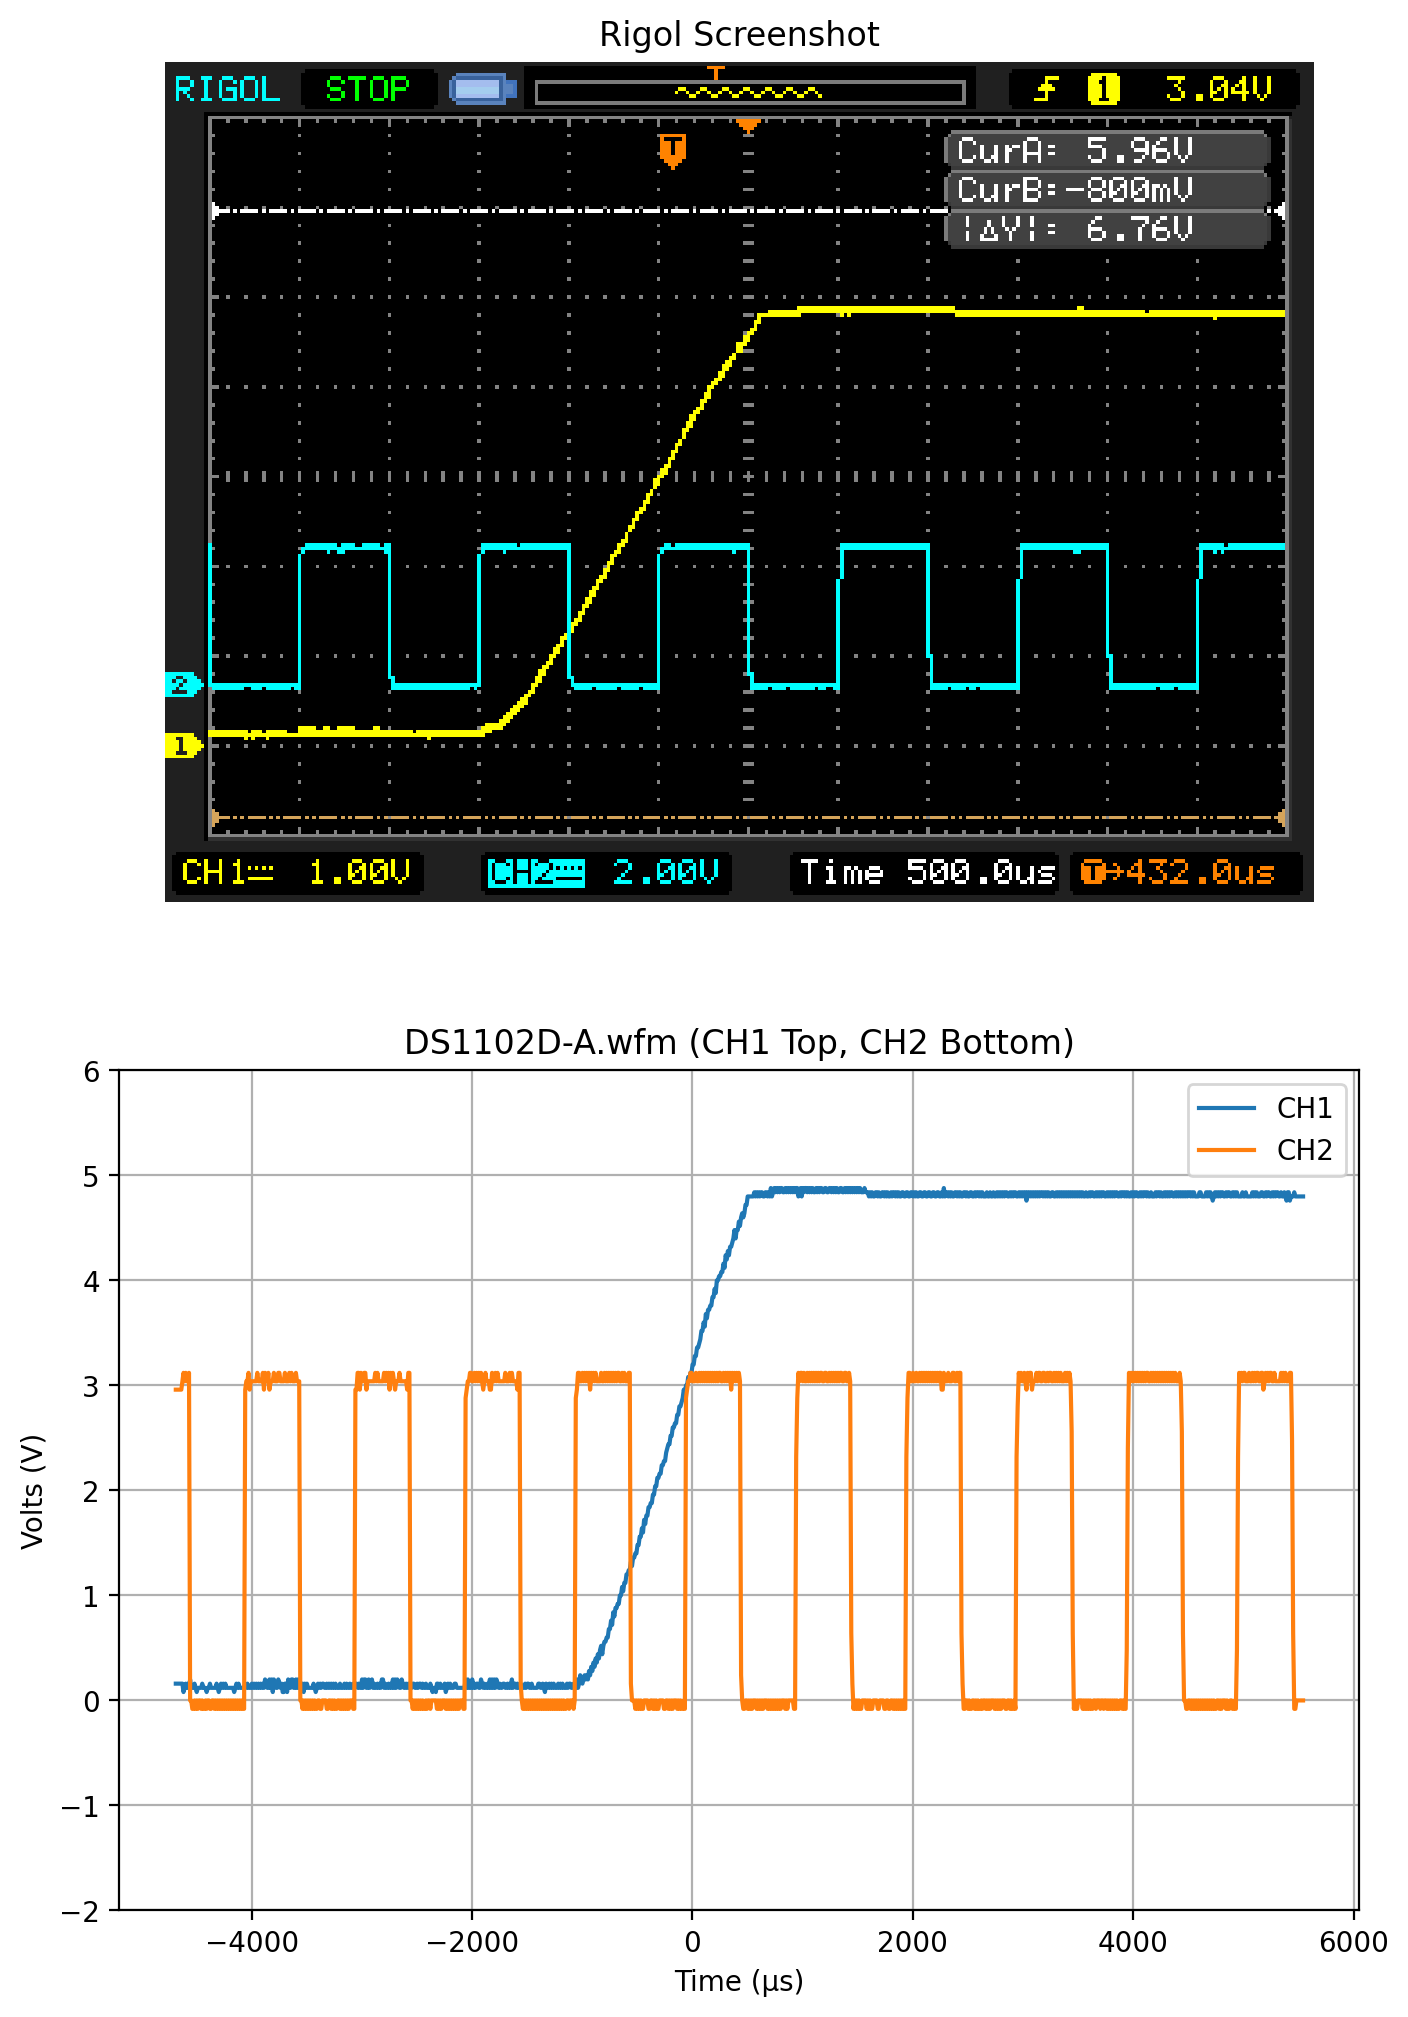

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102D-A.wfm?raw=true'


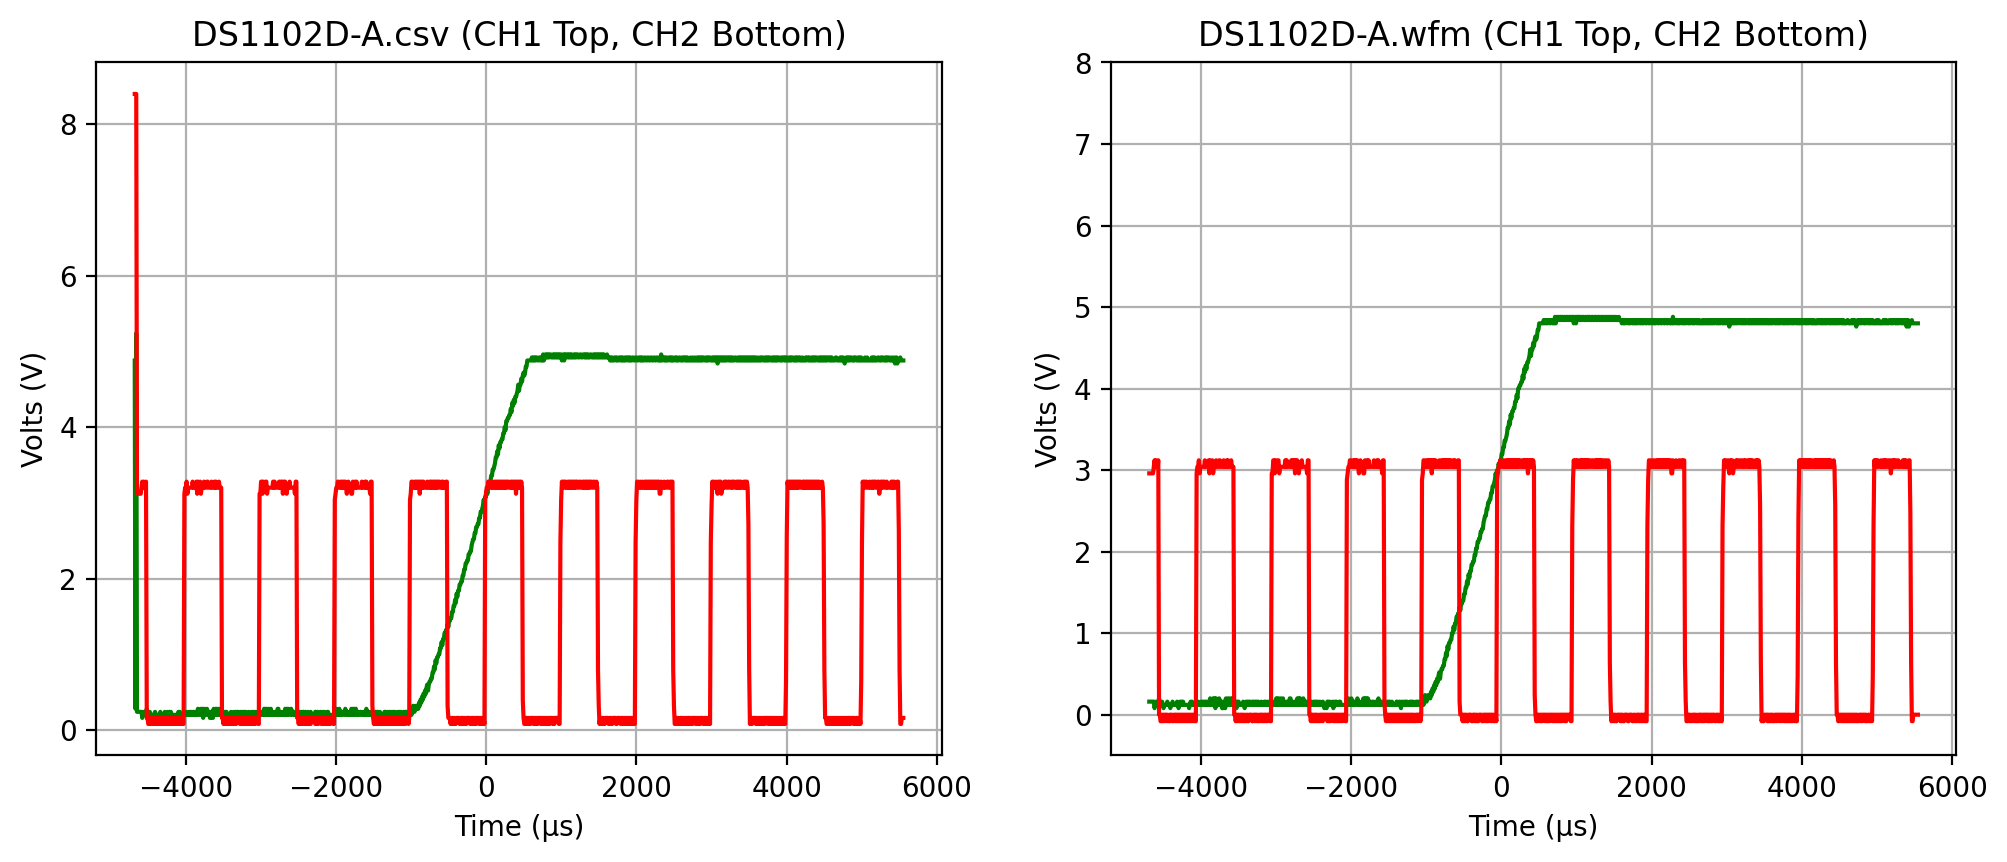

In [4]:
side_by_png("DS1102D-A", ch=[1, 2], offset=[0, 0])
plt.ylim(-2, 6)
plt.show()

side_by_csv("DS1102D-A", ch2_offset=0)
plt.ylim(-0.5, 8)
plt.show()

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102D-A.wfm?raw=true'


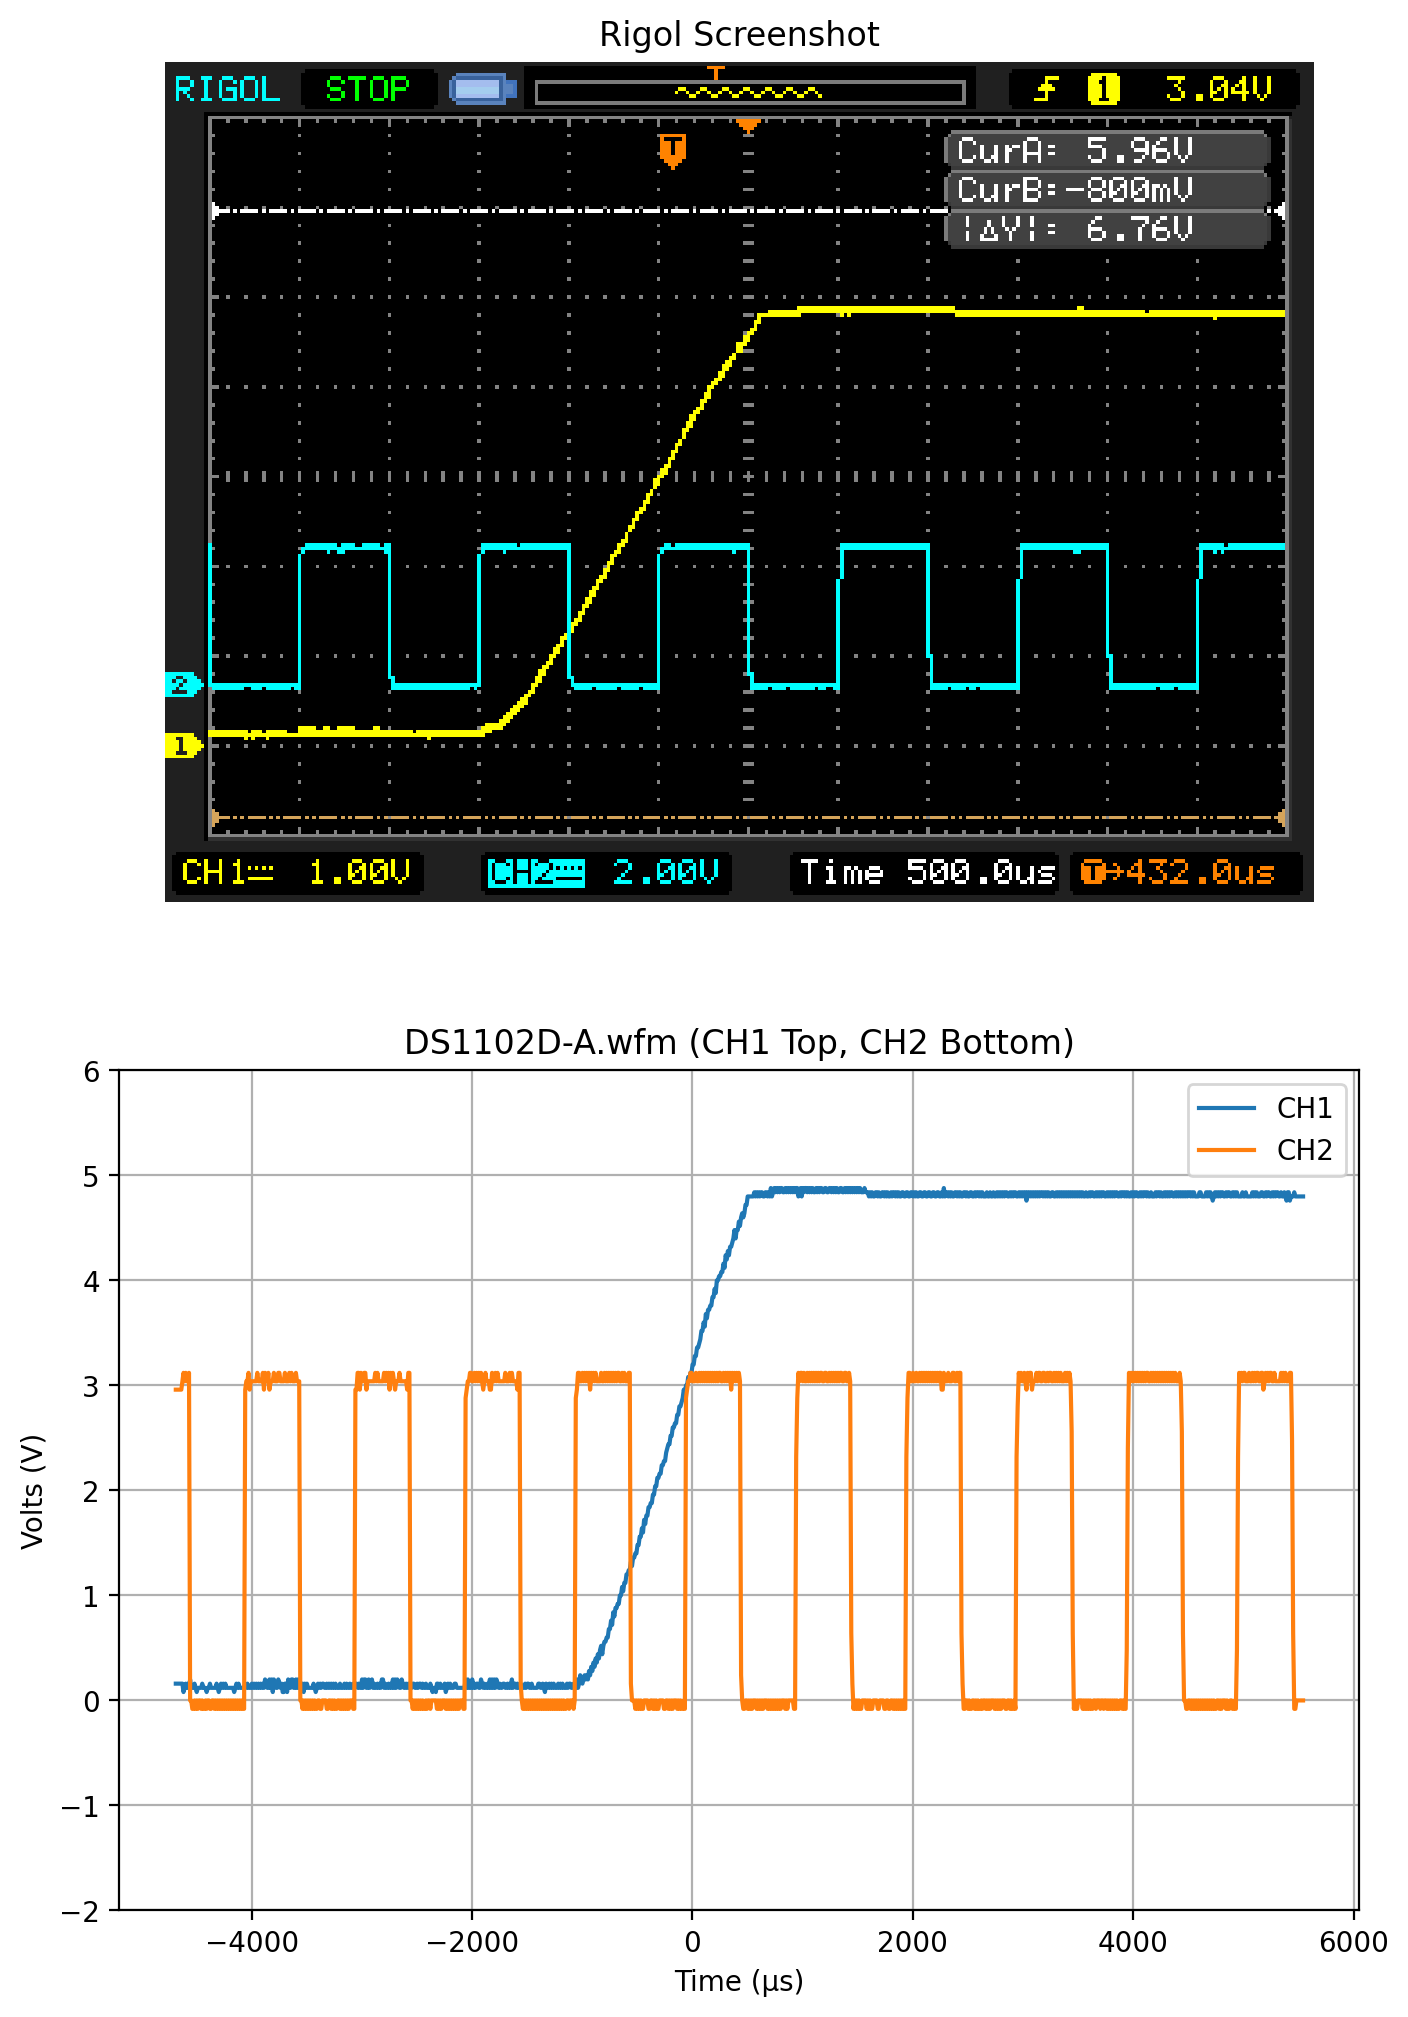

In [5]:
side_by_png("DS1102D-A", ch=[1, 2], offset=[0, 0])
plt.ylim(-2, 6)
plt.show()

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102D-A.wfm?raw=true'


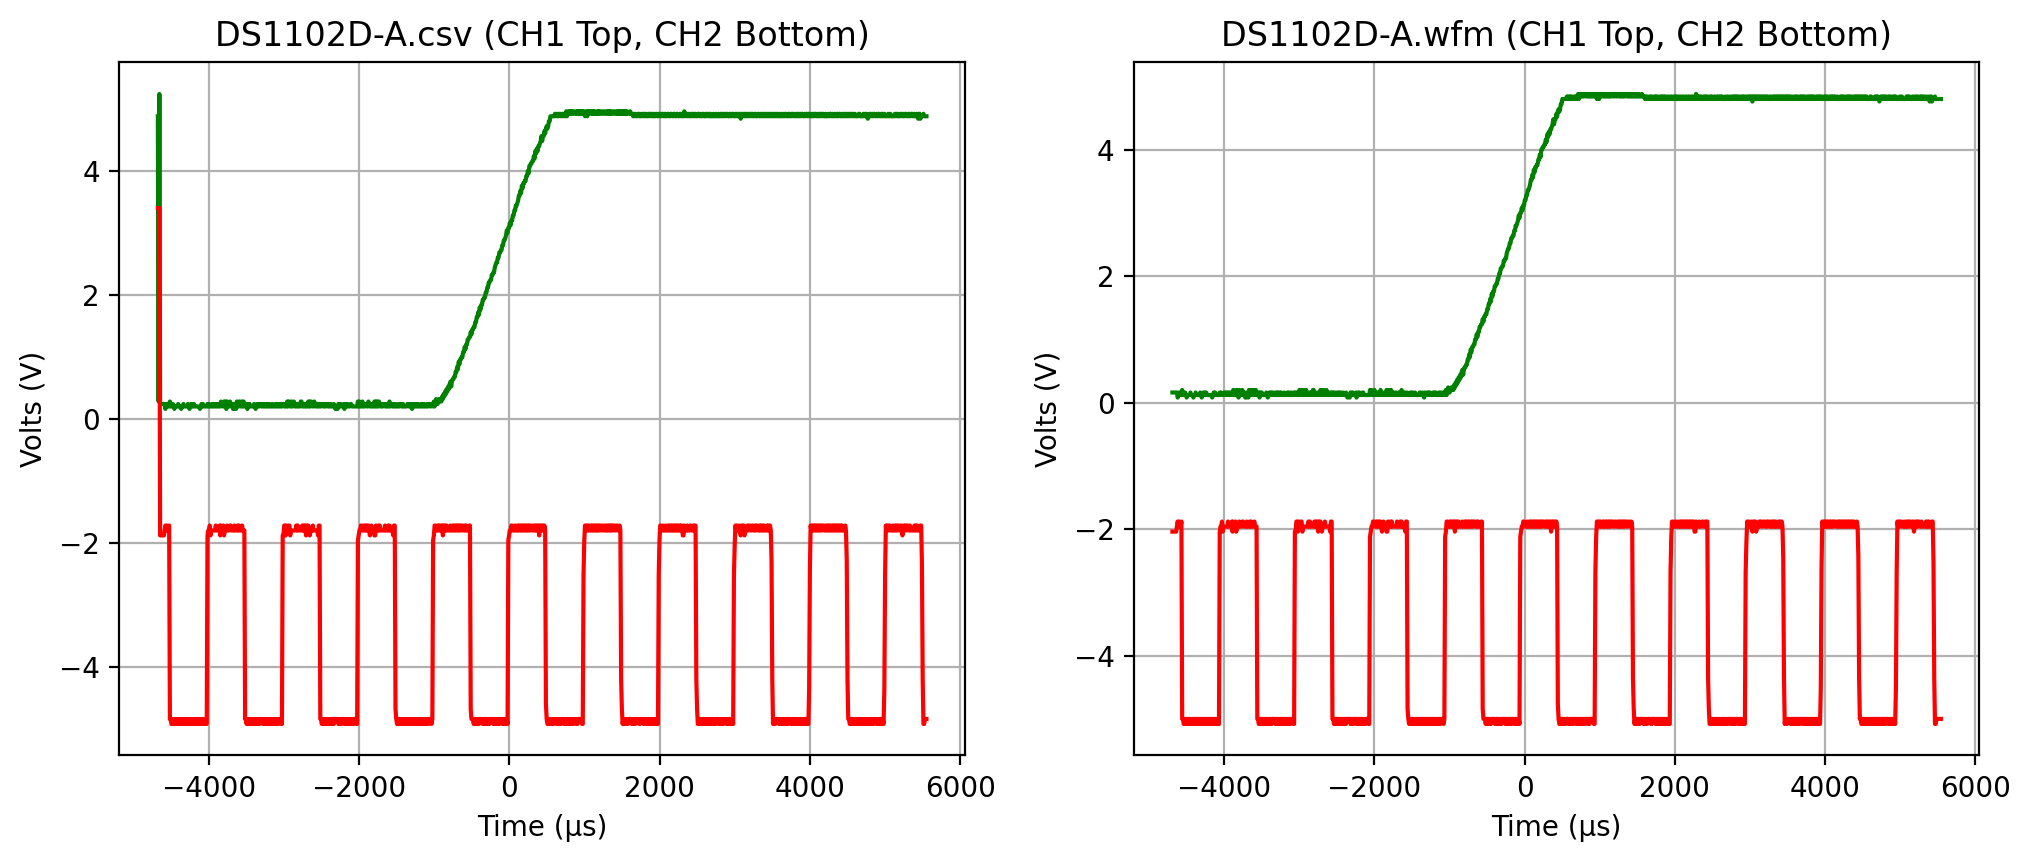

In [6]:
stem = "DS1102D-A"
side_by_csv(stem, ch2_offset=-5)